## Lecture 13

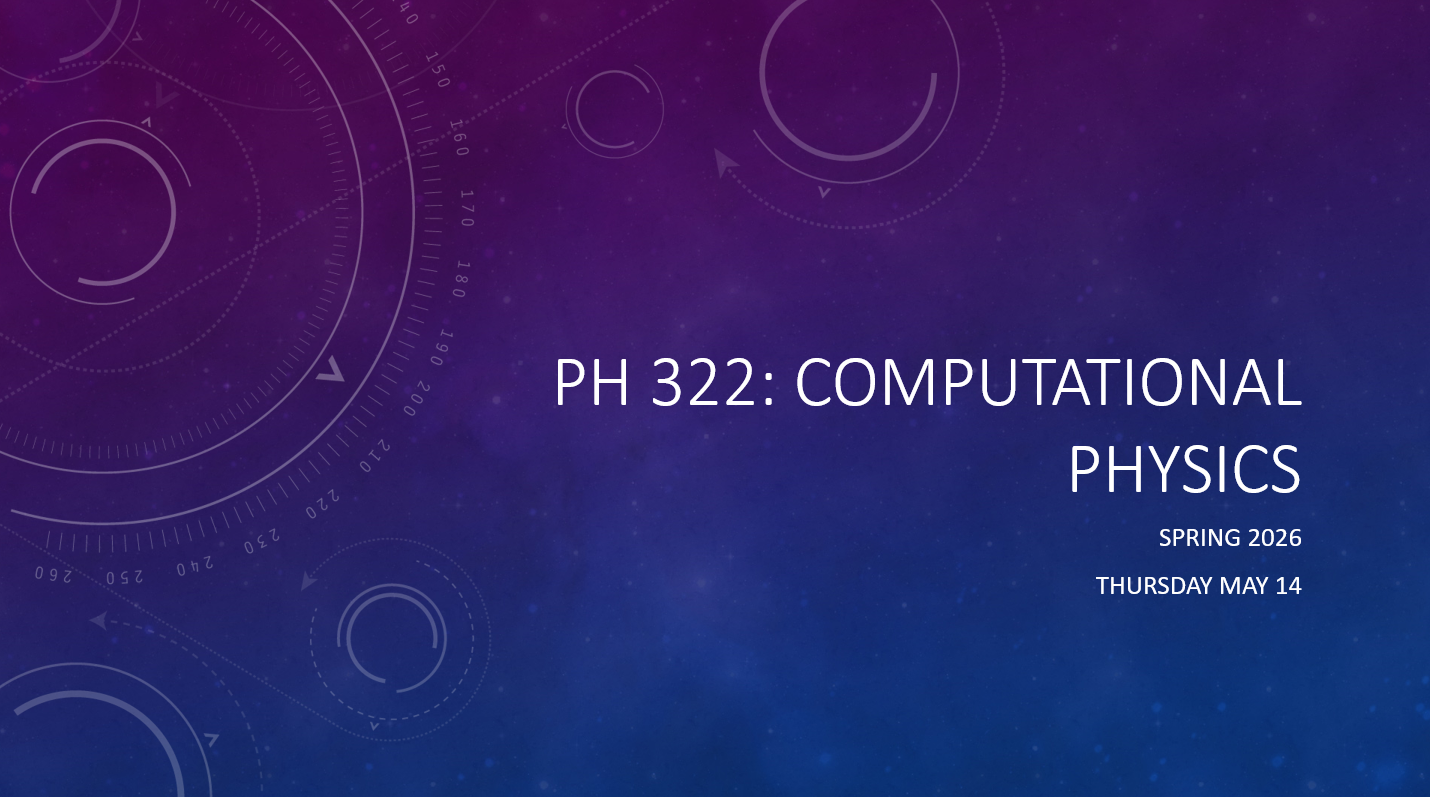

In [1]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Lectures\\Figures\\header_lecture13.png"))

**Announcements**
* HW 7 is available. Due Tuesday, May 19.


**Last Class**
* 2nd-order ODEs.
* System of 2nd-order ODEs.
* Adaptive step method.
* Adpative step method with more than one variable. 

**Today's Class**
* Boundary value ODEs - Shooting method
* Partial differential equations
* Laplace Equation
* Jacobi method
* Gauss-Seidel method
* Overrelaxation



### Practice Exercise -  The non-linear pendulum

Let's practice this method by solving the non-linear pendulum equation.
A pendulum consists of a (massless) rod of length $l$ and bob of mass $m$. The angle of displacement is measured from the vertical. Assume no friction at the pivot point. 


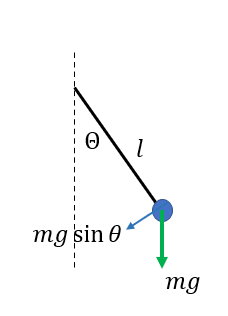

We can write Newton's second law as:


$$
m\frac{d^2(l\theta)}{dt^2} = -mg\sin{\theta}
$$

where $\frac{d^2(l\theta)}{dt^2}$ is the tangential acceleration of the pendulum.

Simplifying, we get:

$$
\frac{d^2\theta}{dt^2} = -\frac{g}{l}\sin{\theta}.
$$

Next, we cast the 2nd-order equation into two first-order equations by defining a new variable $y$ equal to the first derivative of $\theta$:

$$
\frac{d\theta}{dt} = y.
$$

Doing so, the original ODE becomes:

$$
\frac{dy}{dt} = -\frac{g}{l}\sin{\theta}.
$$

We write these two equations in vector form as:

$$
\mathbf{r}=(\theta,y),
$$ 

$$
\mathbf{f}(\mathbf{r},t) = [y, -\frac{g}{l}\sin{\theta} ].
$$

The original 2nd-order ODE is now in a form we can code and solve using one of our ODE methods.

Solve the non-linear pendulum problem use the Euler's method for simplicity to find the solution $\theta(t)$. 

Since this is a 2nd-order equation, we need to specify two initial conditions. Assume the pendulum starts at rest, with an initial displacement angle of $\theta_0 = 45^{\circ}$. Find the solution over the time interval $t=0, 5s$.

Plot $\theta(t)$ and $y(t)$ vs. t. Does your graph make physical sense?

**For reference:**

**First-order Euluer's method**

$
\boldsymbol{r}(t+h) = \boldsymbol{r}(t) + h\boldsymbol{f}(\boldsymbol{r},t)
$


**Fourth-order RK**

$
\begin{array}{l}
\boldsymbol{k_1}  &=  h\boldsymbol{f}(\boldsymbol{r},t) \\
\boldsymbol{k_2} &=  h\boldsymbol{f}(\boldsymbol{r}+\frac{1}{2}\boldsymbol{k_1}, t+\frac{1}{2}h) \\
\boldsymbol{k_3} &=  h\boldsymbol{f}(\boldsymbol{r}+\frac{1}{2}\boldsymbol{k_2}, t+\frac{1}{2}h) \\
\boldsymbol{k_4} &=  h\boldsymbol{f}(\boldsymbol{r}+\boldsymbol{k_3}, t+h) \\
\boldsymbol{r}(t+h) &= \boldsymbol{r}(t) + \frac{1}{6}(\boldsymbol{k_1}+2\boldsymbol{k_2}+2\boldsymbol{k_3}+\boldsymbol{k_4})
\end{array}
$

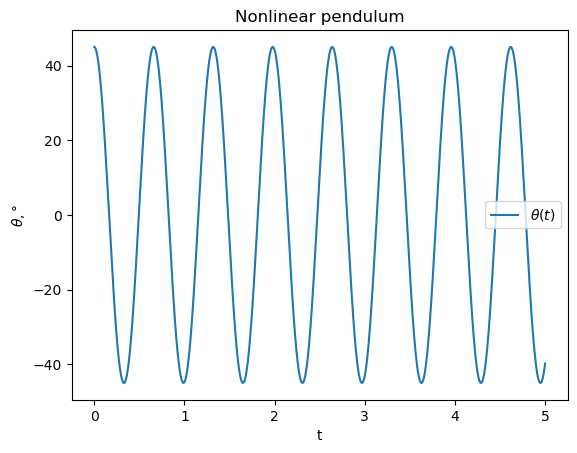

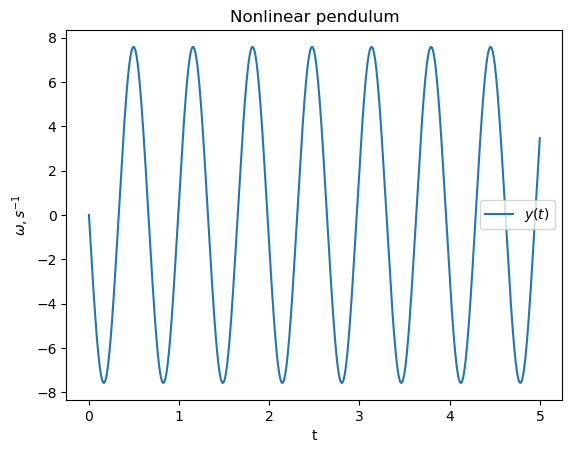

In [4]:
# 4th-order Runge-Kutta method to solve a 2nd-order differential equation that depends on a single variable



Notably the solution $\theta(t)$ is not a perfect sine wave as it is for the linear pendulum case. 

**Experiment with the pendulum**

In the case of a linear pendulum, the period is independent of the amplitude. Is this also true for a nonlinear pendulum? Experiment by changing the initial $\theta$.
 
We can also explore how the oscillation changes with gravity. For example, what is the oscillation for the same pendulum on the moon where the acceleration due to gravity is 1/6 g?




**Animate the pendulum**

Just for fun, we can use vpython to visualize the pendulum. Here I use the vpython cylinder object to draw the pendulum arm, and a sphere for the bob. 

I calculate the x,y position of the bob and the end of the arm at every timestep, and change the frame rate accordingly. You can see how relatively simple the code is. 

Note, increase the number of timesteps N above to produce a reasonable animation (N>5000)

In [5]:
# Part b: Animate the pendulum



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Here I repeat the non-linear pendulum problem but using the adaptive time step method.

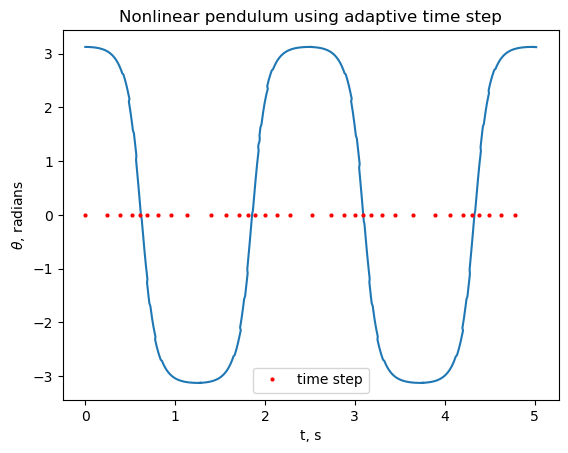

In the top plot I again plot the locations of the time steps using the red dots. You see that they are not evenly spaced but are spaced closer where the solution varies rapidly and are spaced farther apart where the solution varies slowly. The bottom plot is the size of the time step $h$ at each time step. You can see the size changes throughout the integration period. 

<IPython.core.display.Javascript object>

**Conservation of Energy**

In principle, the total energy of pendulum will be conserved since we have not included any dissipative forces like air resistance or friction. 

The total energy of the pendulum is its mechanical energy:

$$
E = \text{potential energy} + \text{kinetic energy}
$$

$$
= mgh + \frac{1}{2}mv^2
$$

$$
= mgl(1-\cos\theta) + \frac{1}{2}m(\omega l)^2,
$$

where $\omega$ is the angular velocity of the pendulum and we are defining the potential energy of the pendulum when $\theta=0$ (vertical).

We can then calulate the total energy at every time step and plot:

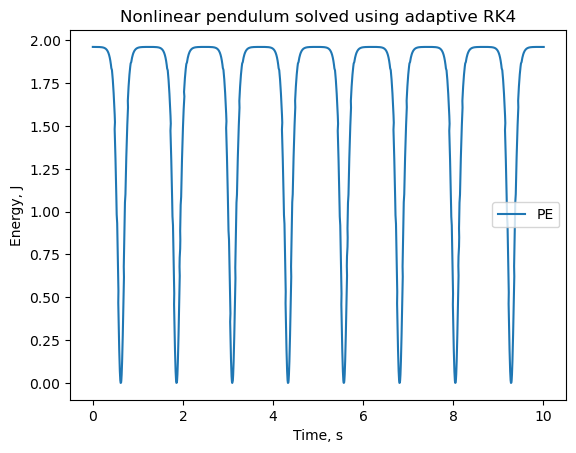

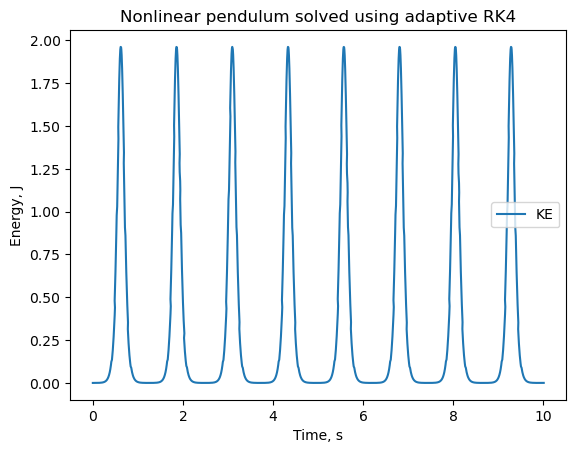

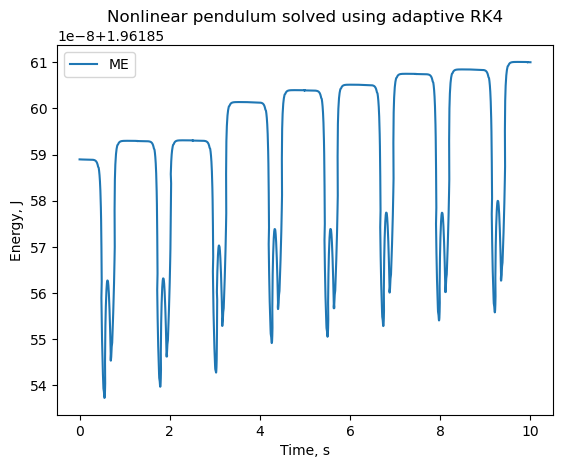

In [11]:
## Total energy vs. time of the nonlinear pendulum
## Uses results from the adaptive step program above

# define function for potential energy
def U(theta):
    # arguments
    # theta: current angular position of pendulum, radians
    ## other constants defined above
    return m*g*l*(1-np.cos(theta))

#define function for kinetic energy
def T(omega):
    # arguments 
    # omega: current angular velocity of pendulum, radians/sec
    ## other constants defined above
    return 0.5*m*(omega*l)**2


m = 1 # mass of pendulum

# create arrays to store PE, KE, and ME at every time step
PE = np.empty(len(tvalues))
KE = np.empty(len(tvalues))
E = np.empty(len(tvalues))

# calculate PE,KE,ME at every time steo
for i in range(len(tvalues)):
    PE[i] = U(vvalues[i])
    KE[i] = T(wvalues[i])
    E[i] = PE[i] + KE[i]

plt.plot(tvalues, PE, label='PE')
plt.xlabel("Time, s")
plt.ylabel("Energy, J")
plt.legend()
plt.title("Nonlinear pendulum solved using adaptive RK4")
plt.show()

plt.plot(tvalues, KE, label='KE')
plt.xlabel("Time, s")
plt.ylabel("Energy, J")
plt.legend()
plt.title("Nonlinear pendulum solved using adaptive RK4")
plt.show()

plt.plot(tvalues, E, label='ME')
plt.xlabel("Time, s")
plt.ylabel("Energy, J")
plt.legend()
plt.title("Nonlinear pendulum solved using adaptive RK4")
plt.show()



By looking at the total energy plot, we see that energy is not conserved. This perhaps isn't surprising as know there is approximation error at every step. These approximation errors add up over time. This may not be important if the interval of time is small, but for longer time periods,  the amplitude of the pendulum will increase (over decrease in some cases). 

We can improve upon this by decreasing the $\delta$ value, that is, the minimum error on each time step. In the following energy plots, I reduce $\delta$ from $10^{-2}$ to  $10^{-8}$. By reducing $\delta$ we keep the energy constant to within decreasingly smaller error. 

**$\delta=10^{-2}$**
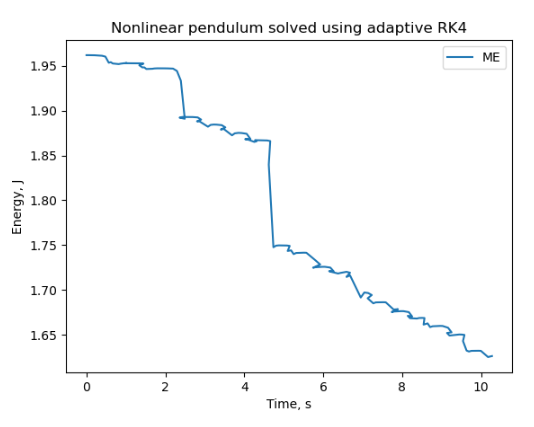


**$\delta=10^{-4}$**
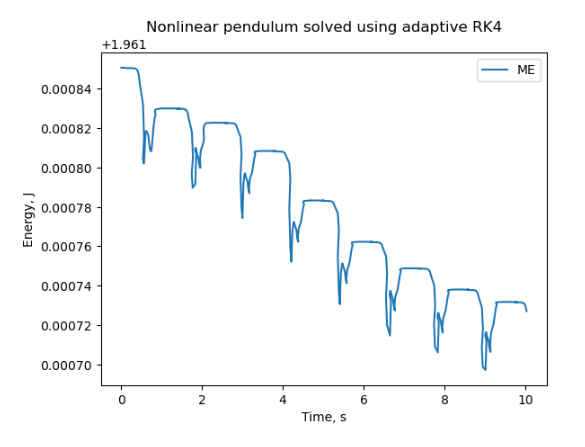

**$\delta=10^{-6}$**
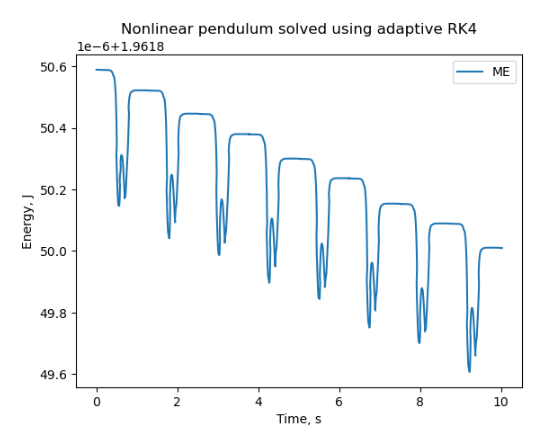

**$\delta=10^{-8}$**
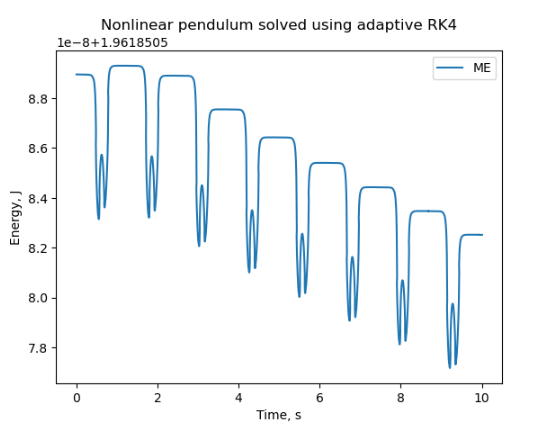

There are ODE solvers that do a better job than RK at conserving energy. We won't get into these, but one such method, the "leap-frog" method is described in our textbook.

## Boundary value problems

As we know, in order to solve differential equations we need to specify boundary conditions. At least one boundary condition for each first-order equation we wish to solve, meaning two conditions for a 2nd-order equations.

Until now, these boundary conditions have been initial conditions, that is we specify the value of the function at the beginning of the time interval. This makes the solution relatively easy to calculate, since we can just start at the beginning and work our way to the end of the interval.

But boundary conditions need not only be initial conditions. A boundary condition may for example be a condition that must be met at the end of the interval. For example, you want to know what angle you need to throw a beanbag to land exactly at some distance $x$. 

You can see we can't satisfy this boundary condition in the usual way, since we aren't given the initial conditions.

**Shooting method**

Though there are a number of methods to solve boundary value problems, most rely on trial and error. That is, you guess an initial condition that might cause the solution to pass through the boundary condition. Likely it won't. But based on the result you update your initial condition and try to get closer. Repeat until you hit the boundary condition within your required degree of accuracy.


The **shooting method** does just that as illustrated below.

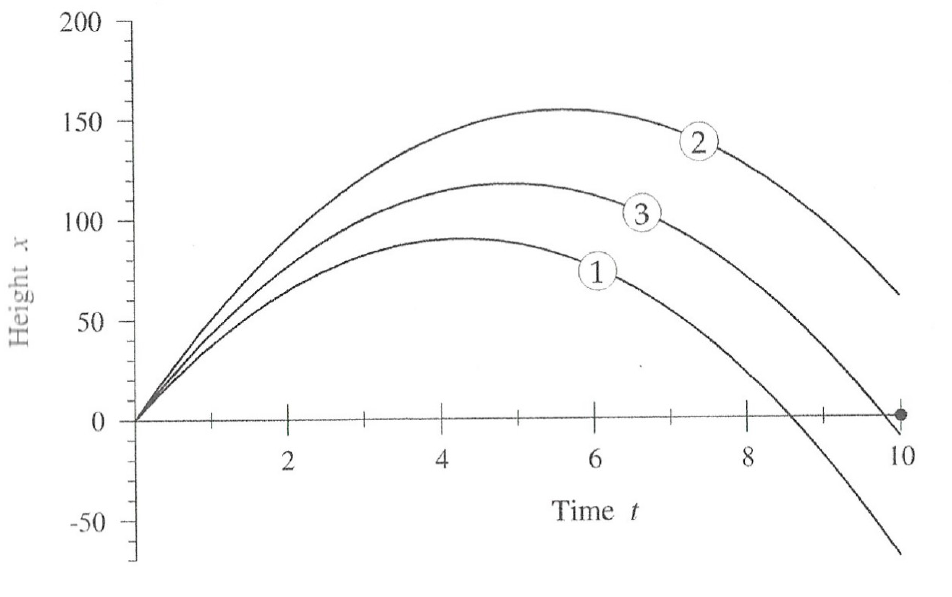





**Figure 8.11**

Consider solving the differential equation:

$$
\frac{d^2y}{dt^2} = -g
$$

that governs the flight of a ball without air resistance, where $y$ is the height of the ball.  One of the boundary conditions is that the solution has to pass through y=0 m, at t=10s. That is the ball must last land at t=10s. We are not given the initial velocity. 

We then guess an initial velocity, $v_1$, and using one of our ODE methods, say 4th-order RK, we calculate the solution up to the end of the interval.


Likely we'll find the height of the ball is not 0 m at t=10s. So we update our guess for the initial velocity. We continue until the height of the ball is 0 m at t=10s.

### Binary search and boundary value problems

The biggest question is, how do we update our guess of the initial velocity for each iteration?

Well consider that each initial velocity $v_0$, produces a solution at t=10s, call it $y$. Therefore we effectively have a function for the height of the ball $y(v_0)$. 

We want to find $v_0$ such that $y(v_0)=y_t$, where $y_t=0$ m in this case, or equivalently;

$$
y(v_0)-y_t = 0
$$

or 

$$
f(v_0)=0,
$$

where $f(v_0) = y(v_0)-y_t$.


Written in this form, our task is find the roots of the function $f$, that is for what value of $v_0$ is $f=0$? 

But this is just the type of equation we solved earlier this term using methods such as *binary search*. So the basic idea here is to use a binary search method to find the initial condition such that the solution satisfies the boundary condition. 


Remember, in the binary search method we bracket the root, and evaluate the function over multiple iterations until we hone in on the solution.

The only real difference here is that the function $f(v_0)$ is a bit more complicated because it requires us to compute one complete solution of $y(t)$ using Runge-Kutta or other methods for each choice of $v_0$, in order to get an estimate of the boundary value. But other than that the binary search algorithm proceeds in the same way.

To solve the boundary-value problem requires us to merge two of our methods, the binary search (or other root-finding method) and the 4th-order RK (or other ODE method).

To perform the RK method, we need to break the 2nd-order equation into two  1st-order equations:

$$
\frac{d^2y}{dt^2} = -g
$$

Break this into two 1st-order equations:

$$
\frac{dy}{dt} = v
$$

$$
\frac{dv}{dt} = -g
$$

Boundary conditions:

$$
y=0, t=0 \qquad x=0, t=10
$$


Since we need to calculate the solution to these differential equations for every guess of our initial velocity, it is best if we write a function that performs the Runge-Kutta method for any choice of $v_0$. The only variable that changes every time we compute a new solution is the initial velocity, so we only need to pass $v_0$ to the function.

Otherwise we can just copy our previous code for binary search and Runge-Kutta methods. 

### Pointers for coding the ODE boundary value problem

Let's see what the code looks like. 

* The program includes a function $f_v()$ that returns $y'(v_0, \text{t=10s})-y_t$, the difference between calculated height at t=10 seconds, and the boundary condition. 
* Within the function I define the vector $\mathbf{f}(\mathbf{r},t)$ which returns the functions $f_y$, $f_v$, which are needed to solve the differential equation. 
* I set the initial velocity equal to the velocity that is passed to $f_v()$. 
* I need to bracket the correct initial velocity. So I choose 0 m/s as my lower estimate and 100 m/s as my upper estimate. In general I need to test whether the root lies between these two. 
* I use my binary search code from earlier problems pretty much as is, and use the value of the function $f_v(v_0)$ in my search. 
* If I want to plot the solution, I will also need to return $y$ at all time steps. This isn't necessary if you only want to know the correct initial velocity.

The optimal initial velocity is 48.557 m/s.


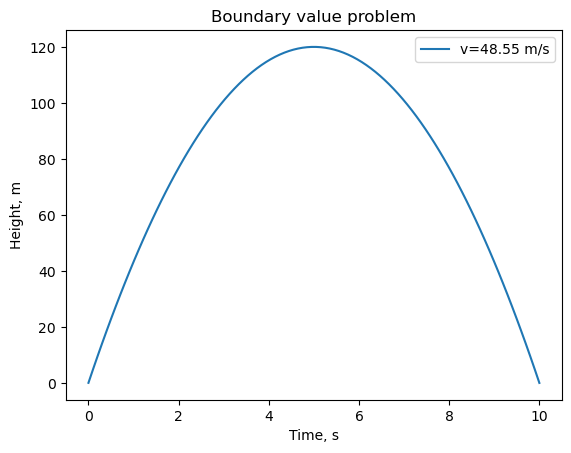

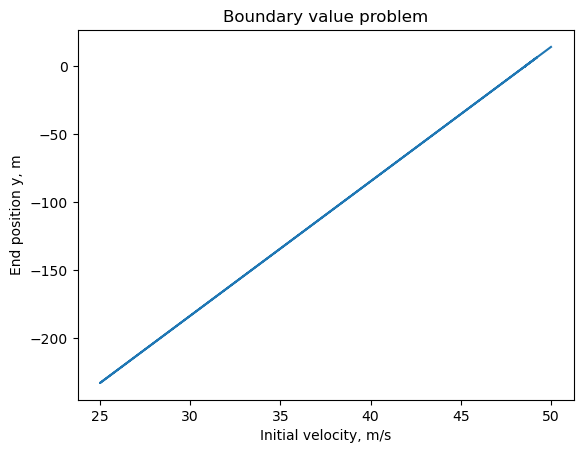

In [16]:
# Use binary search and 4th-order RK to solve boundary value problem



This should give you a general idea how to solve differential equations with boundary conditions. There are other methods including the relaxation method, where we make an initial guess about the solution across the entire time interval but fixed at the boundary value. We then recalculate the solution using this guess and continue iterating until the solution converges, just like in the relaxation method we used to solve nonlinear equations. We will use this method in the next chapter where we solve partial differential equations. 

## Chapter 9 Partial differential equations

We next learn numerical methods to solve partial differential equations (PDEs). A number of famous physics equations are PDEs including the wave equation and Schroedinger's equation. Unlike ordinary differential equations, PDEs have more than one independent variable, so they require different techniques to solve them (although we will use Euler's method in one technique). 

Consider the electromagnetic wave equation in one dimension. Here the equation includes not only the derivative of the wave function in time, but the derivative of the function in space: 

$$
\frac{\partial^2 E(x,t)}{\partial x^2}  =\frac{1}{c^2}\frac{\partial^2 E(x,t)}{\partial t^2}
$$

The equation contains both time $t$ and position $x$ as independent variables, so the solution $E(x,t)$ is a 2D function. 

Just like ordinary differential equations, PDEs require boundary conditions to solve. Since PDEs often include position variables as independent variables, PDEs often have boundary conditions along a spatial dimension, in addition to initial conditions.

We will look at solving partial differential equations with spatial boundary conditions first, then move on to initial conditions. 

### Laplace equation - Electrostatics with no charges

The canonical PDE boundary value problem is to calculate the electric potential inside a box with conducting walls. The lower three walls are in electrical contact and grounded so are all at zero potential. The upper wall however is not in contact with the lower walls and is kept at a potential $V$. This is a *Dirichlet condition*, when the function is specified along its boundaries.  

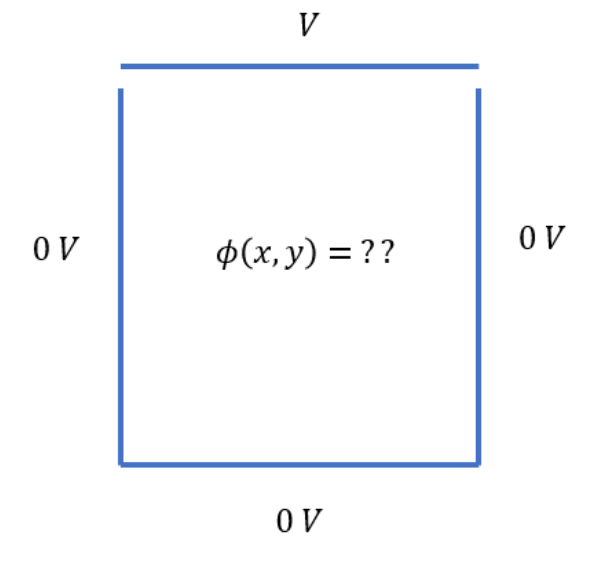

In this case, the potential along the boundaries of the box constrain what the potential function inside the box will be.  We will use Gauss's Law to derive the governing partial differential equation for the potential $\phi$. 

We start with the integral form of Gauss's Law for the electric field, which states:

$$
\oint_{S} \mathbf{E} \cdot d\mathbf{A} = \frac{Q_{enc}}{\epsilon_0}
$$

Here $\oint_{S} \mathbf{E} \cdot d\mathbf{A}$ is the surface integral of the electric field $\mathbf{E}$ over a closed surface $S$ and $Q_{\text{enc}}$ is the total charge enclosed by that surface. 


According to the divergence theorem, the surface integral of a vector field over a closed surface is equal to the volume integral of the divergence of that field over the volume enclosed by the surface:

$$
\oint_S \mathbf{E} \cdot d\mathbf{A} =\int_V(\nabla \cdot \mathbf{E}) 
$$

Applying this to Gauss's Law we get:

$$
\int_V(\nabla \cdot \mathbf{E}) = \frac{Q_{enc}}{\epsilon_0}
$$

The total charge $Q_{enc}$ within the volume $V$ can be expressed as a volume integral of the charge density $\rho$:

$$
Q_{enc} = \int_V \rho dV
$$

Substituting this expression into the equation, we get:

$$
\int_V (\nabla \cdot \mathbf{E}) \, dV = \frac{1}{\epsilon_0} \int_V \rho dV
$$

Since this equation holds for any arbitrary volume $V$, we can equate the integrands:

$$
\boxed{\nabla \cdot \mathbf{E} = \frac{\rho}{\epsilon_0}}
$$

This is the differential form of Gauss's Law. It states that the divergence of the electric field at any point in space is equal to the charge density at that point divided by the permittivity of free space.

Since there are no electric charges inside the box, this becomes:

$$\nabla \cdot \mathbf{E} = 0
$$

And since the electric field and potential are related by

$$
\mathbf{E} = -\nabla\phi,
$$

we can combine the two equations to get

$$-\nabla \cdot \nabla\phi = 0,
$$

or

$$\nabla \cdot \nabla\phi = 0,
$$

which in two dimensions is



$$\nabla \cdot \nabla\phi  = \left(\frac{\partial}{\partial x}, \frac{\partial}{\partial y}\right) \cdot \left(\frac{\partial \phi}{\partial x}, \frac{\partial \phi}{\partial y}\right) = \frac{\partial^2 \phi}{\partial x^2} +  \frac{\partial^2 \phi}{\partial y^2} = 0,
$$

which is Laplace's equation, a second-order partial differential equation:

$$
\boxed{\frac{\partial^2 \phi}{\partial x^2} +  \frac{\partial^2 \phi}{\partial y^2} = 0}
$$

### Finite difference methods to solve PDEs

The first numerical method we'll use to solve partial differential equations is a *finite difference* method.  There are a number of different finite difference methods, but in all, the basic approach is to discretize the solution space by dividing the solution space into a grid of finite points. The solution at each point is found by numerically approximating the partial derivaties at each grid poiont as a finite difference between neighboring grid points. This turns the partial differential equation into a system of linear equations which we can solve using a number of techniques, including the *relaxtion* and *Forward-time Centered-space* methods.

Finite difference methods can used to solve a number of classes of PDEs including the Laplace equation, Poisson equation, wave equation, and the diffusion equation. 

We apply the finite difference method here to solve the Laplace equation above.

First we break up our function space into a grid of equal sized cells with cell width $a$:

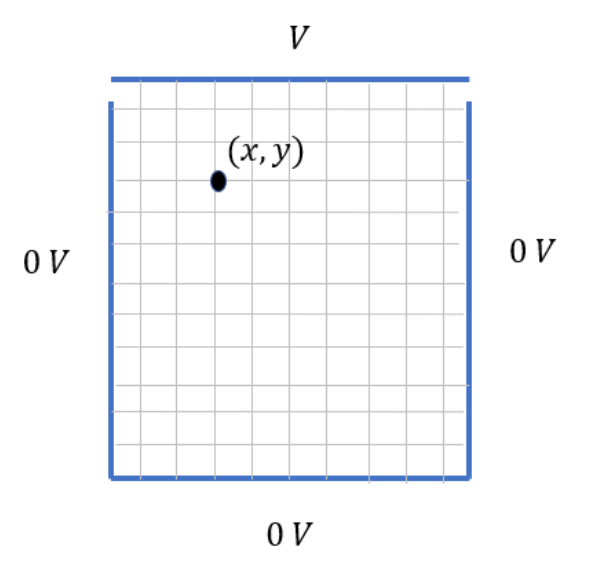


The spacing of the grid cells doesn't necessarily have to be uniform but for our purposes we will make them even (though they don't look that way above).

We calculate the partial derivative at each grid cell point $(x,y)$ using the central difference approximation we learned in Chapter 6.

Let's write out the partial second derivatives using central differences (see section 5.10.5 for a review of second derivatives) in each dimension at grid point $(x,y)$. The spacing between grid points in both dimensions is $a$. To estimate the partial derivative with respect to $x$, we find the difference in the function $\phi$ between neighboring grid cells along the $x$ dimension, while hold the $y$ variable constant, and vice versa for the partial derivative with respect to $y$:

$$
\frac{\partial^2\phi}{\partial x^2} = \frac{\phi (x+a,y) + \phi(x-a,y) - 2\phi(x,y)}{a^2},
$$

$$
\frac{\partial^2\phi}{\partial y^2} = \frac{\phi (x, y+a) + \phi(x, y-a) - 2\phi(x,y)}{a^2}.
$$

With these definitions, we can write Laplace's equation as:

$$
\frac{\partial^2\phi}{\partial x^2} + \frac{\partial^2\phi}{\partial y^2}  = \frac{\phi (x+a,y) + \phi(x-a,y) - 2\phi(x,y) + \phi (x, y+a) + \phi(x, y-a) - 2\phi(x,y)}{a^2}
$$

$$
= \frac{\phi (x+a,y) + \phi(x-a,y) + \phi (x, y+a) + \phi(x, y-a) - 4\phi(x,y)}{a^2} = 0
$$

If we multiply both sides by $a^2$, Laplace's equation becomes:

$$
\phi (x+a,y) + \phi(x-a,y) + \phi (x, y+a) + \phi(x, y-a) - 4\phi(x,y)= 0
$$

So at each grid point we will have an equation like this. 

Notice the LHS of the equation is just the sum of the potential at every grid point around point (x,y) minus 4 times the potential at the grid point (x,y) itself:

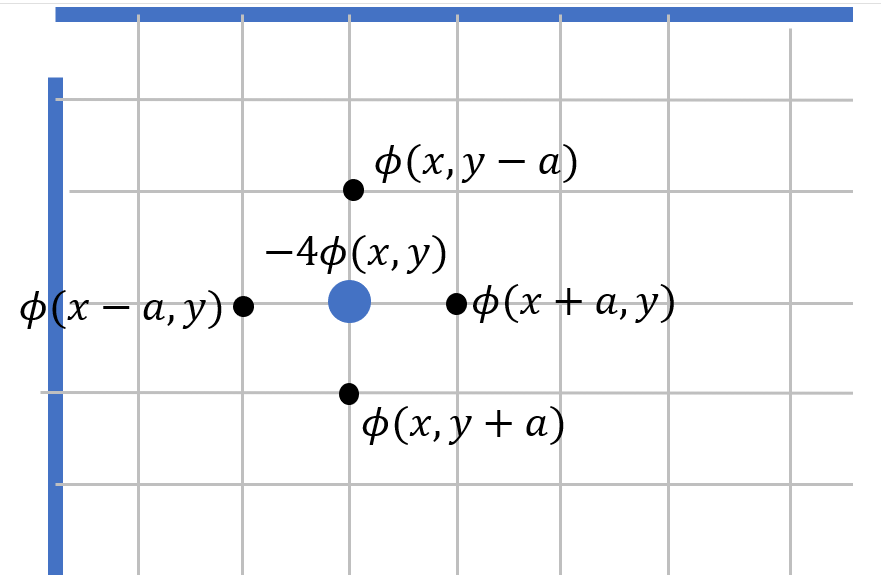

So if we have $N\times N$ grid points, we will have $N\times N$ equations, with $N\times N$ unknowns. The unknowns of course are the values of the potential at each $N\times N$ grid point. 

Notice also, that each of the unknowns is a linear term, there are no higher powers of $\phi$. So we have reduced the second-order partial differential equation into a system of linear equations to solve. 

### Jacobi method  - Relaxation method revisited

We can use any of our methods to solve the $N\times N$ system of linear equations including Gaussian elimination or LU decomposition, but we can also solve using the *relaxation method*, which we learned earlier this term, and is easier to code. 

Remember the relaxation method requires us to make an initial guess of the solution for all the variables in our system of equations. We then calculate the value of the function at each grid point using those guesses. We determine if the solution has converged to our target error, and if not, we use the current estimate to calculate the next one.

Remember also when we use the relaxation method,  we have to get our equations into the form:

$
x = f(x,y,..)
$

$
y = g(x,y,..)
$

So too here, so we write the equations as:

$$
\phi(x_0,y_0) = \frac{1}{4}\left(\phi (x_0+a,y_0) + \phi(x_0-a,y_0) + \phi (x_0, y_0+a) + \phi(x_0, y_0-a) \right).
$$

$$
\phi(x_0,y_1) = \frac{1}{4}\left(\phi (x_0+a,y_1) + \phi(x_0-a,y_1) + \phi (x_0, y_1+a) + \phi(x_0, y_1-a) \right).
$$

$$
\phi(x_0,y_2) = \frac{1}{4}\left(\phi (x_0+a,y_2) + \phi(x_0-a,y_2) + \phi (x_0, y_2+a) + \phi(x_0, y_2-a) \right).
$$

$$
\ldots,
$$

or in general,
$$
\phi(x_i,y_j) = \frac{1}{4}\left(\phi (x_i+a,y_j) + \phi(x_i-a,y_j) + \phi (x_i, y_j+a) + \phi(x_i, y_j-a) \right),
$$

We have one of these equations at each grid point $(x_i,y_j)$.

Since in this problem the boundary conditions are known, we only solve for $\phi(x_i,y_i)$ at the interior grid points. So if our set of grid points is of size $M\times N$, in Python we initially fix the values of $\phi(x,y)$ along the boundary as:

(first row)
$
\phi(0,:)=V \qquad \text{top wall} 
$

(last row)
$
\phi(M-1,:) = 0 \qquad \text{bottom wall} 
$

(first column)
$
\phi(:,0) = 0 \qquad \text{left wall} 
$

(last column)
$
\phi(:, N-1) = 0 \qquad \text{right wall} 
$

We then have $(M-2)\times(N-2)$ interior grid points, and $(M-2)\times(N-2)$ equations, and  $(M-2)\times(N-2)$ unknowns.

We make an initial guess of these unknowns and perform the relaxation method until the solution converges. 

To test for convergence we require that all $(M-2)\times(N-2)$ solutions converge, by simply comparing the current iteration with the previous one. This method to solve systems of linear equations is called the **Jacobi method** and benefits from being simple to implement. 

### Practice Exercise - Solve Laplace equation using the Jacobi method. 

Solve the Laplace equation for the problem above. Set the potential at the top boundary to be 1 volt and zero along the other three walls. Calculate the potential over an $N\times N$ grid of size $N=100$ to an accuracy of $10^{-3}$ V.

Let's think about the pseudocode first.

* Create a user-defined function to calculate $\phi(x,y)$ using the equation above at each grid cell.
* Create an array of *NxN* which will store the solution $\phi$.
* Initialize $\phi$ at all grid points, including along the boundaries. 
* Use a ```while```-loop to test for convergence.
    * Create a copy of $\phi$ that will hold the estimated solutions from the previous iteration.
    * Loop over each **inner** grid point in the $\phi$ array using a nested ```for```-loop.
        *  Update your estimate of $\phi$ at grid point $(i,j$) using the previous estimate of $\phi$, now stored in your copy of $\phi$.
    * Check if $\phi$ has converged at each grid point (you can also check for this condition in your ```while``` statement). 
* Note, make sure you update only the inner grid points. The boundary values must remain constant. 

The equation for $\phi(x,y)$ above contains the grid spacing $a$. What will this be?

When you get your code working, make an image plot of your solution. Does it look reasonable? Count the number of iterations it takes for the solution to converge. Decrease the target error to $10^{-4}, 10^{-5}, \ldots$ and compare the number of iterations for each. 

It took 243 iterations to converge.


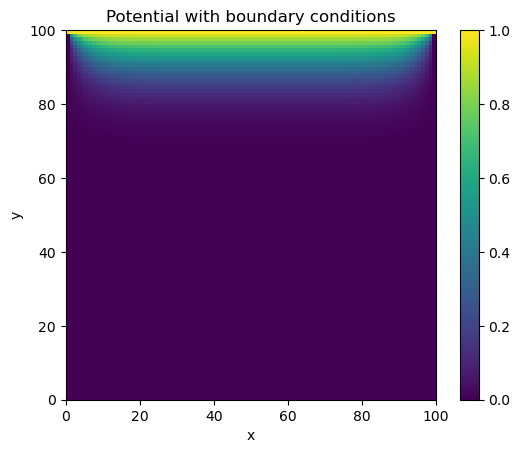

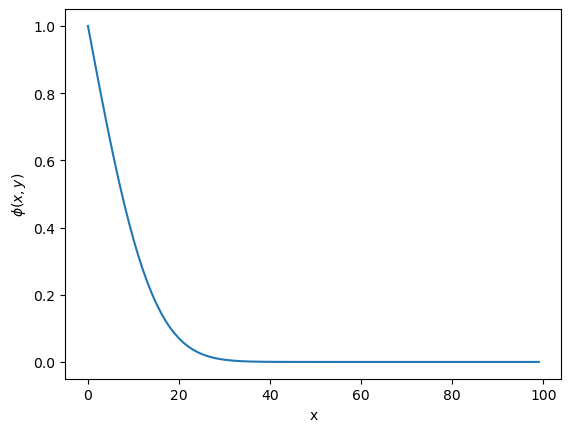

 ### The Gauss-Seidel method.

The main disadvantage of the Jacobi method we've used above is it's slow. If I decrease the target error to $10^{-6}$, which is still a relatively modest target, it takes over 10,000 iterations to converge. 

The next two methods we'll go over, the **Gauss-Seidel** and  **overrelaxation** methods, produce similarily accurate results but faster, in the case of the overrelaxation method much faster, and there is very little work to actually modify our Jacobi code to implement them. So they are both kind of a no-brainer.

The Gauss-Seidel method is so simple, you may have invented it yourself without knowing it, or are already using it.

In the traditional relaxation method, such as the Jacobi method we used above, we used the array of the previous solution in order to calculate each element in the new solution. That is to say, if the array $\mathbf{x}$ stored all the elements from the previous solution, the Jacobi method says to calculate the new solutions from all of these previous solutions, as this figure shows:

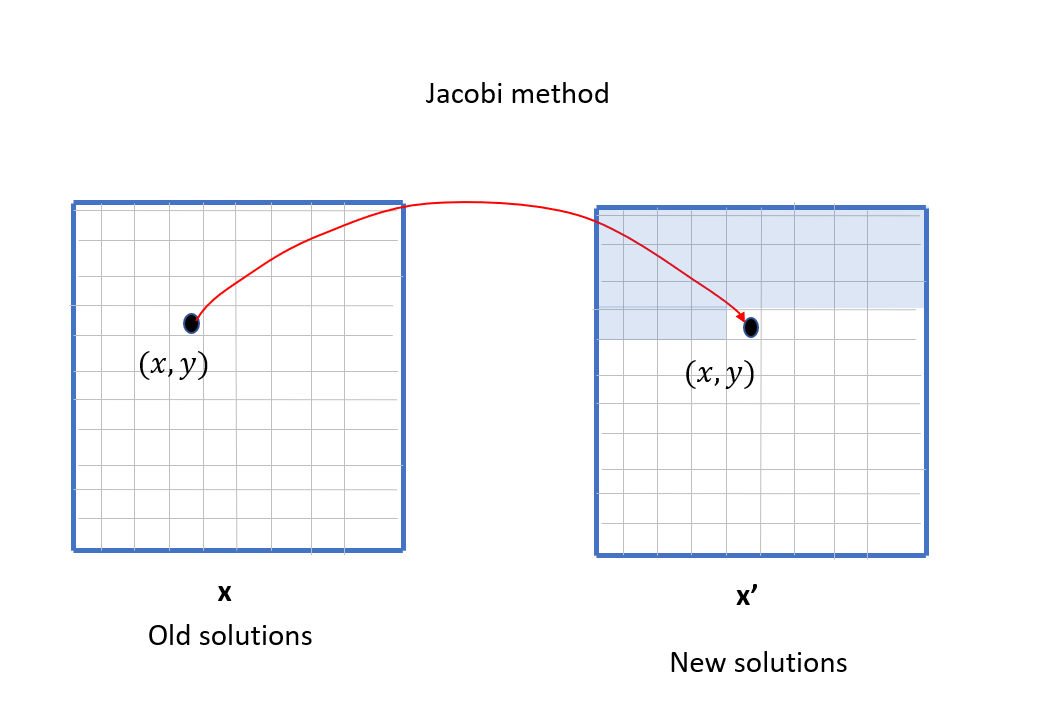

That's fine, but we can do better. 

In the figure, the shaded cells are cells where we have already calculated a new solution. Notice that the calculation of $\phi$ in the current grid cell (x,y) would use some of the new solutions, if they were made available to the calculation. And in most cases the new solutions are improvements over the old solutions. So if the current calculation could use them, the solution will likely converge faster.

So that is the "trick" if you want to call it that, of the Gauss-Seidel method. We simply update our array that stores the solutions with the new ones as soon as we calculate them. That will allow later calculations of the potential in later grid cells to benefit from them. 

I illustrate the Gauss-Seidel method like this:


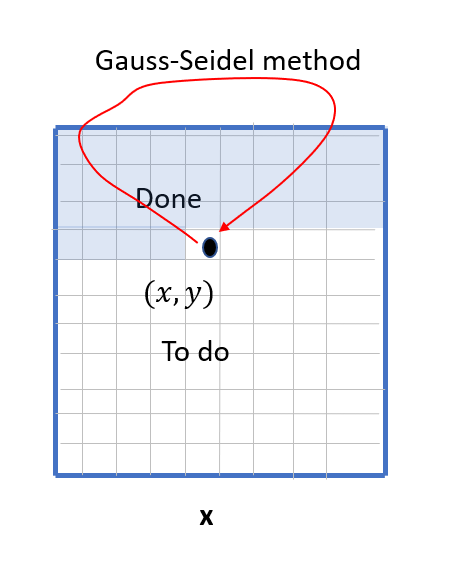

The illustration shows just one array. We don't need an intermediate array to store our new solutions, we just update the current element in the one array we use to store the potential. I indicate this with the arrow that passes the solution back to the same element in the array. 

The code to do this in Python is simple, in fact you may have already done this when you solved the relaxation problem from Chapter 6.

Let's say that we use the array *solution* to store the current solution of the relaxation method. We calculate the new solution by passing this array to our function *phi()* that calcuates the new solution.  We simply pass the result from *phi* back into solution like this:

```python
# inside a nested for loop
solution[j,i] = phi(i,j,solution)
```

Python evaluates assignment statments like this from right to left. So it will first evaluate *phi()* using the "done" solutions to calculate the new solution at (x,y) (or index j,i in my sample code), and pass this back into the array solution. 

### Practice exercise - Gauss-Seidel method

If you have your Jacobi method working from above, copy it here. Revise it to perform the Gauss-Seidel method. Compare the number of iterations for both methods to converge. Again, change the target error, and compare the number iterations with the iterations from using the Jacobi method. 

It took 1451 iterations to converge.


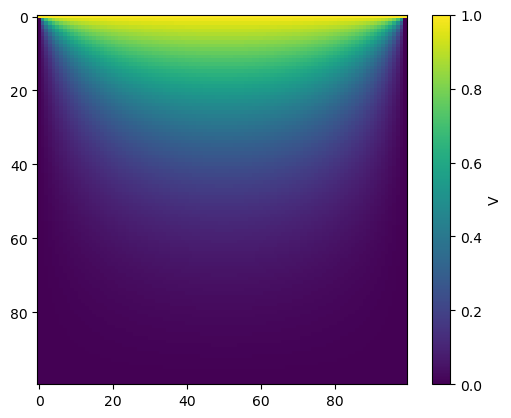

One other thing to note about the revised code. Since I need to compare the new solution with the previous solution, I make a copy of solution[j,i] and save it in the variable *store*. This is just a scalar variable, not an array. 

I find it now takes 235 iterations to converge vs. 243 with the Jacobi method, for a target error of 1e-3 V, and 1451 vs 1897 iterations for an error of 1e-4 V, so there is an improvement, but slight.  

### Overrelaxation method

The Gauss-Seidel trick saves a little bit of time, but not much. 

The overrelaxation method however can save a significant of computation time, and is easy to code to boot.

The basic idea of the overrelaxation method is illustrated below:

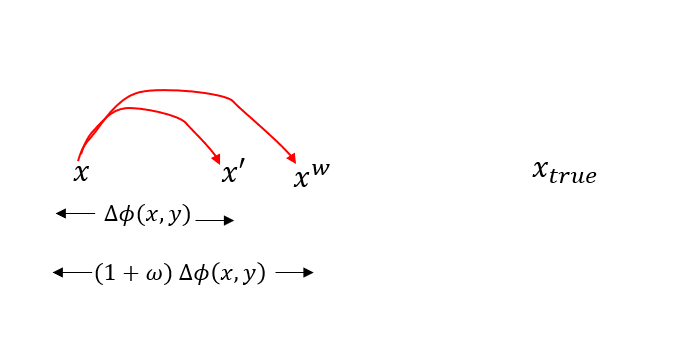

In the relaxation method, each solution gets us a little bit close to the true solution. If $x$ is the  current guess of the solution, then in the next iteration the guess is improved to $x'$. We then move our solution from $x$ to $x'$.

Overrelaxation "asks", if the hop from $x$ to $x'$ moves us closer to $x_{true}$, why not hop just a little bit more?

So let's go back to the Laplace equation problem. We can write the new solution $\phi'(x,y)$ as:

$$
\phi'(x,y) = \phi(x,y) + \Delta \phi(x,y)
$$

where $\Delta \phi(x,y)$ is just the difference, or the hop, between the two. 

Overrelaxation "says", let's hop a little bit more, by an amount $(1+\omega)\Delta \phi(x,y)$, where $\omega > 0$.  Doing so the next step will be at:

$$
\phi_w(x,y) = \phi(x,y) + (1+\omega)\Delta \phi(x,y)
$$


And since $\Delta \phi(x,y) = \phi'(x,y) -\phi(x,y)$, 

substituting in above, we get


$$
\phi_w(x,y) = \phi(x,y) + (1+\omega)(\phi'(x,y) -\phi(x,y))
$$

$$
= (1+\omega)\phi'(x,y)  -\omega \phi(x,y)
$$

For $\phi'(x,y)$ we use the equation we derived above for Laplace's equation:

$$
\phi(x,y)' = \frac{1}{4}\left(\phi (x+a,y) + \phi(x-a,y) + \phi (x, y+a) + \phi(x, y-a) \right)
$$

Substituting in above: 

$$
\boxed{\phi_w(x,y)= \frac{1+\omega}{4}[\,\phi (x+a,y) + \phi(x-a,y) + \phi (x, y+a) + \phi(x, y-a)]\, -\omega \phi(x,y))}
$$


The boxed equation is the **overrelaxation** method applied to the Laplace equation. It is a minor adjustment to our normal relaxation method, and in many cases can reduce the amount of iterations needed for our solution to converge. 

The only remaining question, is what value to choose for $\omega$? There is no value that will be best all the time, so some trial and error is needed. But to ensure the solution remains stable, it's best to choose a value less than one. So in many cases, 0.9 is a good choice. 

### Practice Exercise - Gauss-Seidel with overrelaxation 

Repeat the above practice exercise but now using the combined overrelaxation and Gauss-Seidel methods. Everything else about the problem is the same. Use $\omega=0.9$.

Solution converged in 91 iterations


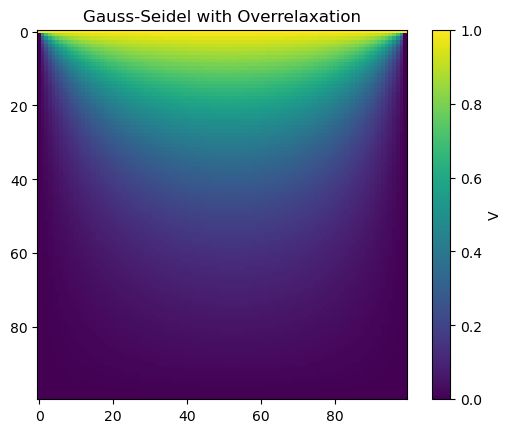